Load and inspect metrics

In [11]:
import pandas as pd

df = pd.read_csv("/Users/rohan/Documents/Final year/cwe_project/scripts/classification_report_updated.csv")

print("Total CWEs:", df.shape[0])
df.head()

Total CWEs: 118


,label,precision,recall,f1_score,support,train_samples
0,CWE114,0.9955,0.9910,0.9932,1336,1424
1,CWE121,0.9997,0.9993,0.9995,12158,11950
2,CWE122,0.9876,0.9994,0.9934,12700,13051
3,CWE123,0.8421,0.9697,0.9014,462,370
4,CWE124,0.9927,0.9982,0.9954,4356,4763


Categorize CWEs by Sample Size

In [12]:
def sample_category(n):
    if n < 100:
        return "Very Low (<100)"
    elif n < 500:
        return "Low (100–500)"
    elif n < 2000:
        return "Medium (500–2000)"
    else:
        return "High (>2000)"

df["sample_group"] = df["support"].apply(sample_category)

df["sample_group"].value_counts()

sample_group
Very Low (<100)      48
Low (100–500)        31
Medium (500–2000)    20
High (>2000)         19
Name: count, dtype: int64

In [13]:
def failure_type(row):
    if row["recall"] < 0.5 and row["precision"] >= 0.8:
        return "False Negatives (Missed)"
    elif row["precision"] < 0.5 and row["recall"] >= 0.8:
        return "False Positives (Over-predict)"
    elif row["precision"] < 0.5 and row["recall"] < 0.5:
        return "Unstable"
    else:
        return "Stable"

df["failure_type"] = df.apply(failure_type, axis=1)

df["failure_type"].value_counts()

failure_type
Stable                            77
Unstable                          26
False Negatives (Missed)           9
False Positives (Over-predict)     6
Name: count, dtype: int64

In [15]:
df.groupby("sample_group")[["precision", "recall", "f1_score"]].mean()

,precision,recall,f1_score
sample_group,,,
High (>2000),0.982753,0.997405,0.989826
Low (100–500),0.716832,0.533548,0.531200
Medium (500–2000),0.816210,0.874735,0.837270
Very Low (<100),0.518262,0.516885,0.480056


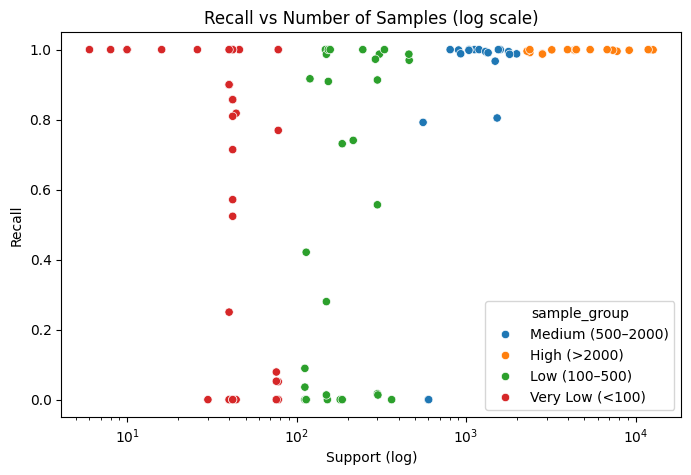

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["support"],
    y=df["recall"],
    hue=df["sample_group"]
)
plt.xscale("log")
plt.title("Recall vs Number of Samples (log scale)")
plt.xlabel("Support (log)")
plt.ylabel("Recall")
plt.show()

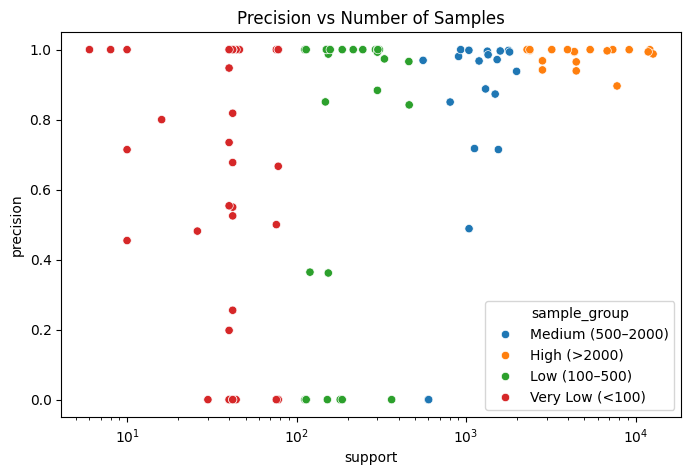

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df["support"],
    y=df["precision"],
    hue=df["sample_group"]
)
plt.xscale("log")
plt.title("Precision vs Number of Samples")
plt.show()

In [20]:
final_table = df[[
    "label", "support", "precision", "recall", "f1_score",
    "sample_group", "failure_type"
]].sort_values(by="support")

final_table.to_csv("cwe_error_analysis.csv", index=False)
final_table.head(10)

,label,support,precision,recall,f1_score,sample_group,failure_type
55,CWE440,6,1.0000,1.00,1.0000,Very Low (<100),Stable
97,CWE674,8,1.0000,1.00,1.0000,Very Low (<100),Stable
71,CWE500,10,1.0000,1.00,1.0000,Very Low (<100),Stable
80,CWE562,10,0.7143,1.00,0.8333,Very Low (<100),Stable
79,CWE561,10,0.4545,1.00,0.6250,Very Low (<100),False Positives (Over-predict)
115,CWE835,16,0.8000,1.00,0.8889,Very Low (<100),Stable
83,CWE571,26,0.4815,1.00,0.6500,Very Low (<100),False Positives (Over-predict)
82,CWE570,30,0.0000,0.00,0.0000,Very Low (<100),Unstable
17,CWE222,40,1.0000,0.25,0.4000,Very Low (<100),False Negatives (Missed)
23,CWE247,40,0.9474,0.90,0.9231,Very Low (<100),Stable
